In [1]:
import sys, os
import json, pickle
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
import pandas as pd
import time as pytime
import statsmodels.tsa.stattools as tsa
import ruptures as rpt
sys.path.append('../..')
import InsanallyLabEphysTools as ilep
from scipy.stats import gaussian_kde, sem, ttest_ind, ttest_rel, norm, mannwhitneyu, linregress, wilcoxon
from tqdm import tqdm
from types import SimpleNamespace
from sklearn import linear_model
from sklearn.model_selection import KFold
import seaborn as sns
import traceback
from itertools import product
import pingouin as pg

plt.rcParams['legend.fontsize'] = 'small'
plt.rcParams['axes.labelsize'] = 'medium'
plt.rcParams['axes.formatter.limits'] = [-2,3]
plt.rcParams['axes.formatter.use_mathtext'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['figure.dpi'] = '150'

#Set global font parameters
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Arial'
#Set font type to TrueType for compatibility
plt.rcParams['pdf.fonttype'] = 42
plt.rcParams['ps.fonttype'] = 42
stdfont = 14
stdyfrac = 0.06
opto_thresh = 1.8
control_thresh = 3.5

TARGET_COLOR = '#ff3654'
NONTARGET_COLOR = '#5776ff'
CR_COLOR = '#808080'
NCR_COLOR = '#FF767C'
CNO_COLOR = '#00BFFF'
SWITCH_COLOR = '#B07A3B'
LIGHT_LASER = '#5E92EE'
LASER_COLOR = '#3375E9'
GOOD_GREY = '#969696'
GOOD_GREEN = '#32A852'
NCR_CR_cmap = mpl.colors.LinearSegmentedColormap.from_list('NCR-CR color map', [NCR_COLOR, CR_COLOR], N=1000)
PHASE_COLORS = ['#E2CAE3','#C27AC5','#764979','#B9D3F7','#5181C2','#3C557A']

In [2]:
post_opto = ['BS_86','BS_119','BS_123','BS_128','BS_131','BS_163','BS_174']
post_control =  ['AE_287']

all_animals = np.concatenate([post_opto, post_control])

In [3]:
df = pd.read_csv('../../Source Data Files/Figure 3d.csv')

In [5]:
FRmod_delta_pc_CR = []
FRmod_delta_pc_NCR = []
FRmod_control_delta_pc_CR = []
FRmod_control_delta_pc_NCR = []
for row in df.iloc():
    if row['condition'] == 'opto' and row['category'] == 'CR':
        FRmod_delta_pc_CR.append(row['percent change in FRmod laser on'])
    elif row['condition'] == 'opto' and row['category'] == 'NCR':
        FRmod_delta_pc_NCR.append(row['percent change in FRmod laser on'])
    elif row['condition'] == 'control' and row['category'] == 'CR':
        FRmod_control_delta_pc_CR.append(row['percent change in FRmod laser on'])
    elif row['condition'] == 'control' and row['category'] == 'NCR':
        FRmod_control_delta_pc_NCR.append(row['percent change in FRmod laser on'])


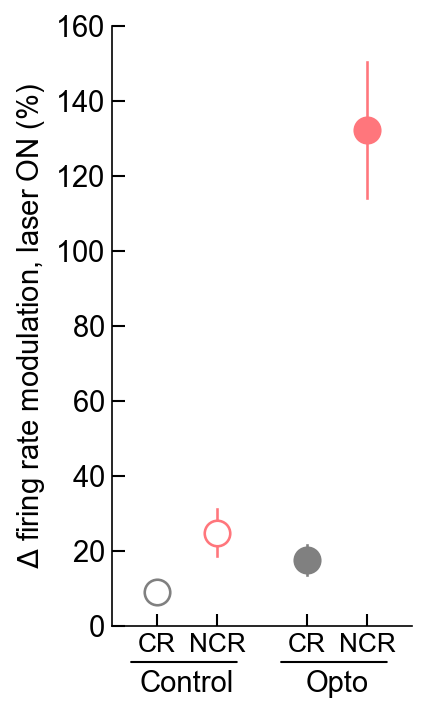

In [6]:
def add_axis_size(fig, ax_w, ax_h, left, bottom):
    fig_w, fig_h = fig.get_size_inches()
    ax = fig.add_axes([left/fig_w, bottom/fig_h, ax_w/fig_w, ax_h/fig_h])
    return ax

def make_axis_size(ax_w, ax_h, left=.3, bottom=.3, right=0, top=0):
    fig_w = (ax_w + left + right) * 1.05
    fig_h = (ax_h + bottom + top) * 1.05
    fig = plt.figure(figsize=(fig_w, fig_h))
    ax = add_axis_size(fig, ax_w, ax_h, left, bottom)
    return fig, ax

fig,ax = make_axis_size(2, 4, left=.3, bottom=.3, right=0, top=0)
switch_offset = 0.25

################################################################################################################

size = 20
summary_size=150
summary_width=1.25#0.75

median_value = np.mean(FRmod_control_delta_pc_CR)
Q1 = median_value - sem(FRmod_control_delta_pc_CR)
Q3 = median_value + sem(FRmod_control_delta_pc_CR)
# Q1, median_value, Q3 = (np.percentile(FRmod_control_delta_pc[mask_CR], q) for q in [25, 50, 75])
ax.scatter([0-switch_offset],[median_value],s=summary_size,fc='white',ec=CR_COLOR,zorder=21,clip_on=False,lw=summary_width)
ax.plot([0-switch_offset]*2,[Q1,Q3],zorder=20,color=CR_COLOR,clip_on=False,lw=summary_width)

median_value = np.mean(FRmod_control_delta_pc_NCR)
Q1 = median_value - sem(FRmod_control_delta_pc_NCR)
Q3 = median_value + sem(FRmod_control_delta_pc_NCR)
# Q1, median_value, Q3 = (np.percentile(FRmod_control_delta_pc[mask_NCR], q) for q in [25, 50, 75])
ax.scatter([1-switch_offset],[median_value],s=summary_size,fc='white',ec=NCR_COLOR,zorder=21,clip_on=False,lw=summary_width)
ax.plot([1-switch_offset]*2,[Q1,Q3],zorder=20,color=NCR_COLOR,clip_on=False,lw=summary_width)


median_value = np.mean(FRmod_delta_pc_CR)
Q1 = median_value - sem(FRmod_delta_pc_CR)
Q3 = median_value + sem(FRmod_delta_pc_CR)
# Q1, median_value, Q3 = (np.percentile(FRmod_delta_pc[mask_CR], q) for q in [25, 50, 75])
ax.scatter([2+switch_offset],[median_value],s=summary_size,color=CR_COLOR,zorder=21,clip_on=False,lw=summary_width)
ax.plot([2+switch_offset]*2,[Q1,Q3],zorder=20,color=CR_COLOR,clip_on=False,lw=summary_width)

median_value = np.mean(FRmod_delta_pc_NCR)
Q1 = median_value - sem(FRmod_delta_pc_NCR)
Q3 = median_value + sem(FRmod_delta_pc_NCR)
# Q1, median_value, Q3 = (np.percentile(FRmod_delta_pc[mask_NCR], q) for q in [25, 50, 75])
ax.scatter([3+switch_offset],[median_value],s=summary_size,color=NCR_COLOR,zorder=21,clip_on=False,lw=summary_width)
ax.plot([3+switch_offset]*2,[Q1,Q3],zorder=20,color=NCR_COLOR,clip_on=False,lw=summary_width)

################################################################################################################
labels = ['CR','NCR','CR','NCR']

ax.set_ylim([0,160])
ylab = ax.set_ylabel(r'$\Delta$ firing rate modulation, laser ON (%)')

ax.set_xlim([-0.75-switch_offset,3.75+switch_offset])
ax.set_xticks([0-switch_offset,1-switch_offset,2+switch_offset,3+switch_offset])
ax.set_xticklabels(labels)

xtick_pos_pre = 0.5-switch_offset
xtick_pos_post = 2.5+switch_offset
Yval = ilep.getPrePostLabelYval(ax.get_ylim(),Yfrac=-2*stdyfrac,log=False)
t1 = ax.text(xtick_pos_pre, Yval, 'Control', ha='center', va='bottom', fontsize=stdfont,color='k')
t2 = ax.text(xtick_pos_post, Yval, 'Opto', ha='center', va='bottom',  fontsize=stdfont,color='k')
ax.annotate('', xy=(0.05, -stdyfrac), xycoords='axes fraction', xytext=(0.43, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))
ax.annotate('', xy=(0.55, -stdyfrac), xycoords='axes fraction', xytext=(0.93, -stdyfrac),arrowprops=dict(arrowstyle='-', color='black'))

ax.tick_params(direction='in', length=6, width=1)

for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
    ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(stdfont)
for item in (ax.get_xticklabels()):
    item.set_fontsize(stdfont*0.9)
    pass

# ttl = ax.set_title(' ')
artists = [ylab,t1,t2]
# fig.savefig(os.path.join('D:\\\\Figures','Manuscript Figures','Opto preferential recruitment with control V'+str(current_version)+'.pdf'),transparent=False,facecolor="white",dpi=400, bbox_extra_artists=(artists), bbox_inches='tight')

In [9]:
pval = mannwhitneyu(FRmod_delta_pc_CR,FRmod_delta_pc_NCR).pvalue

print('Opto CR vs NCR')
print(f'p = {pval}')

Opto CR vs NCR
p = 2.9704083962369005e-14


In [10]:
pval = mannwhitneyu(FRmod_control_delta_pc_CR,FRmod_control_delta_pc_NCR).pvalue

print('Control CR vs NCR')
print(f'p = {pval}')

Control CR vs NCR
p = 0.28186231798068095
